# 📊 Comparaison des modèles Teacher vs Student

Ce notebook compare les performances du modèle DistilBERT fine-tuné (teacher) et du modèle distillé (student) entraîné via knowledge distillation.

### 📦  Chargement des dépendances et configuration

In [2]:
import os
import sys
import time
import psutil
import humanize
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizerFast

# Ajout du chemin racine du projet pour permettre les imports de modules locaux
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from lucenai.training.model import load_best_model_and_tokenizer
from lucenai.training.distillation import load_student_model_and_tokenizer
from lucenai.config.settings import MODEL_PATHS, TRAINING_PARAMS

# Paramètres d'affichage
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


2025-07-12 14:12:11.990097: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-12 14:12:12.029275: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-12 14:12:12.030422: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-12 14:12:12.904365: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in M

### 📄 Chargement du dataset de test

In [3]:
try:
    df_test = pd.read_csv("./data/test.csv")
    print(f"✅ Fichier chargé avec succès, Nombre d'échantillons : {len(df_test)}")
    display(df_test.head(10))
except FileNotFoundError:
    print("❌ Erreur : le fichier spécifié est introuvable.")
except pd.errors.EmptyDataError:
    print("❌ Erreur : le fichier est vide.")
except pd.errors.ParserError:
    print("❌ Erreur : échec de l'analyse du fichier.")
except Exception as e:
    print(f"❌ Une erreur inattendue est survenue : {e}")

✅ Fichier chargé avec succès, Nombre d'échantillons : 857


,id,full_text,clean_text,label
0,1868,"RT @fundstrat: FYI, I respect those who do tec...",fyi i respect those who do technical analysis ...,1
1,4834,"RT @stephanlivera: To understand bitcoin, you ...",to understand bitcoin you must first understan...,0
2,4501,RT @HackRead: Teen hacks Ledger hardware crypt...,teen hacks ledger hardware cryptocurrency wall...,1
3,697,@Trader_Dante Am only interested in your 24k g...,am only interested in your 24k gold bitcoin to...,1
4,3506,New post (Drive Genuine Cryptocurrency bitcoin...,new post drive genuine cryptocurrency bitcoin ...,1
5,4642,HASHING24 via /r/BitcoinMarkets https://t.co/j...,hashing24 via rbitcoinmarkets free at,1
6,1378,"New post: ""College students are using student ...",new post college students are using student lo...,1
7,716,Pullback Ahead? Bitcoin Hits Stiff Resistance ...,pullback ahead bitcoin hits stiff resistance a...,0
8,563,You can simply stake your XP coin without wall...,you can simply stake your xp coin without wall...,1
9,3099,RT @mexc_life: STAGE TWO: ENDING SOON !!!\n\n...,stage two ending soon 1 day to go with eth is ...,1


### 📦 Chargement des modèles Teacher et Student

In [4]:
#  Modèle teacher
teacher_model_path = MODEL_PATHS.best_weights
teacher_tokenizer_path = MODEL_PATHS.best_tokenizer
print(f"📦 Chargement du modèle teacher: {teacher_model_path}")
teacher_model, teacher_tokenizer = load_best_model_and_tokenizer(
    model_path=teacher_model_path,
    tokenizer_path=teacher_tokenizer_path,
)

# Modèles student
student_model_path = MODEL_PATHS.student_weights
student_tokenizer_path = MODEL_PATHS.student_tokenizer 
print(f"\n📦 Chargement du modèle élève: {student_model_path}")
student_model, student_tokenizer = load_student_model_and_tokenizer(
    model_path=student_model_path,
    tokenizer_path=student_tokenizer_path,
)


📦 Chargement du modèle teacher: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model
📥 Loading tokenizer from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/tokenizer
✅ Tokenizer loaded successfully.
🧠 Rebuilding model architecture...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All

🏗️ Building deep architecture...
   ✅ Input layers created
   ✅ DistilBERT integrated
   ✅ [CLS] token extracted
   ✅ Deep classification head added

✅ Model successfully built!
📦 Loading model weights from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model


2025-07-12 14:12:19.982671: W tensorflow/core/util/tensor_slice_reader.cc:97] Could not open /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model: FAILED_PRECONDITION: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model; Is a directory: perhaps your file is in a different file format and you need to use a different restore operator?


✅ Weights loaded successfully.

📦 Chargement du modèle élève: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/student_model/checkpoint/weights
📥 Loading tokenizer from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/student_model/tokenizer
✅ Tokenizer loaded successfully.
🧠 Rebuilding student model architecture...
📋 Distilled model detailed architecture
════════════════════════════════════════════════════════════════════════════════
Model: "StudentModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 64)]                 0         []                            
                                                                                                  
 embedding (Embedding)       (None, 64, 64)               1953408   ['input_ids[0][0]'] 

### ✏️ Préparation des données pour l'inférence

In [5]:
# Tokenizer (doit correspondre à celui utilisé lors de l'entraînement)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def encode_texts(texts, max_len=TRAINING_PARAMS.max_len):
    tokens = tokenizer(
        texts.tolist(),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    return tokens

x_test_tokens = encode_texts(df_test["clean_text"])
y_test = df_test["label"].values


### 📊 Empreinte RAM et Disque

Fonctions pour comparer l’empreinte mémoire (RAM) et la taille sur disque des modèles Teacher et Student.

In [6]:
def get_model_size(model_dir: str) -> str:
    """
    Retourne l'occupation disque du modele dans un format lisible
    """
    total_size = 0
    for dirpath, _, filenames in os.walk(model_dir):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return humanize.naturalsize(total_size)

def get_ram_usage() -> str:
    """
    Retourne l’utilisation actuelle de la RAM du processus dans un format lisible
    """
    process = psutil.Process(os.getpid())
    ram_bytes = process.memory_info().rss
    return humanize.naturalsize(ram_bytes)

In [7]:
print("👨‍🏫 Inférence modèle Teacher...")
x_test_inputs = {
    "input_ids": tf.convert_to_tensor(x_test_tokens["input_ids"], dtype=tf.int32),
    "attention_mask": tf.convert_to_tensor(x_test_tokens["attention_mask"], dtype=tf.int32),
}
teacher_preds = teacher_model.predict(x_test_inputs, verbose=0).flatten()
teacher_disk = get_model_size(MODEL_PATHS.best_weights.parent)
teacher_ram = get_ram_usage()

print("👨‍🎓 Inférence modèle Student...")
student_preds = student_model.predict(x_test_inputs, verbose=0).flatten()
student_disk = get_model_size(MODEL_PATHS.student_weights.parent)
student_ram = get_ram_usage()

# 📦 Affichage des ressources
print("\n📦 Ressources utilisées (RAM & Disque) :")
print(f"👨‍🏫 Teacher — Disque : {teacher_disk} | RAM approx. : {teacher_ram}")
print(f"👨‍🎓 Student — Disque : {student_disk} | RAM approx. : {student_ram}")

👨‍🏫 Inférence modèle Teacher...
👨‍🎓 Inférence modèle Student...

📦 Ressources utilisées (RAM & Disque) :
👨‍🏫 Teacher — Disque : 1.6 GB | RAM approx. : 1.3 GB
👨‍🎓 Student — Disque : 7.8 MB | RAM approx. : 1.2 GB


### 🧠 Prédictions des deux modèles

In [8]:
# Préparer les entrées pour TensorFlow (dict de tensors)
x_test_inputs = {
    "input_ids": tf.convert_to_tensor(x_test_tokens["input_ids"], dtype=tf.int32),
    "attention_mask": tf.convert_to_tensor(x_test_tokens["attention_mask"], dtype=tf.int32),
}

# Prédiction sur le modèle teacher
print("👨‍🏫 Inférence modèle Teacher...")
start_teacher = time.time()
teacher_preds = teacher_model.predict(x_test_inputs, verbose=0).flatten()
end_teacher = time.time()
teacher_time = end_teacher - start_teacher

# Prédiction sur le modèle student
print("👨‍🎓 Inférence modèle Student...")
start_student = time.time()
student_preds = student_model.predict(x_test_inputs, verbose=0).flatten()
end_student = time.time()
student_time = end_student - start_student

# Conversion des probabilités en labels binaires
teacher_labels = (teacher_preds >= 0.5).astype(int)
student_labels = (student_preds >= 0.5).astype(int)

👨‍🏫 Inférence modèle Teacher...
👨‍🎓 Inférence modèle Student...


### ⏱️ Comparaison des temps d'inférence

In [9]:
print("\n📊 Résumé des temps d'inférence :")
print(f"👨‍🏫 Modèle Teacher : {teacher_time:.2f} secondes")
print(f"👨‍🎓 Modèle Student : {student_time:.2f} secondes")
print(f"⚡ Accélération : ×{teacher_time / student_time:.2f} plus rapide (student)")


📊 Résumé des temps d'inférence :
👨‍🏫 Modèle Teacher : 30.58 secondes
👨‍🎓 Modèle Student : 0.10 secondes
⚡ Accélération : ×299.33 plus rapide (student)


### ⚖️ Rapport de classification

In [10]:
print("📘 Teacher model:")
print(classification_report(y_test, teacher_labels))

print("📗 Student model:")
print(classification_report(y_test, student_labels))


📘 Teacher model:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       429
           1       0.98      0.95      0.97       428

    accuracy                           0.97       857
   macro avg       0.97      0.97      0.97       857
weighted avg       0.97      0.97      0.97       857

📗 Student model:
              precision    recall  f1-score   support

           0       0.97      0.35      0.52       429
           1       0.60      0.99      0.75       428

    accuracy                           0.67       857
   macro avg       0.79      0.67      0.63       857
weighted avg       0.79      0.67      0.63       857



### 🔍 Matrices de confusion

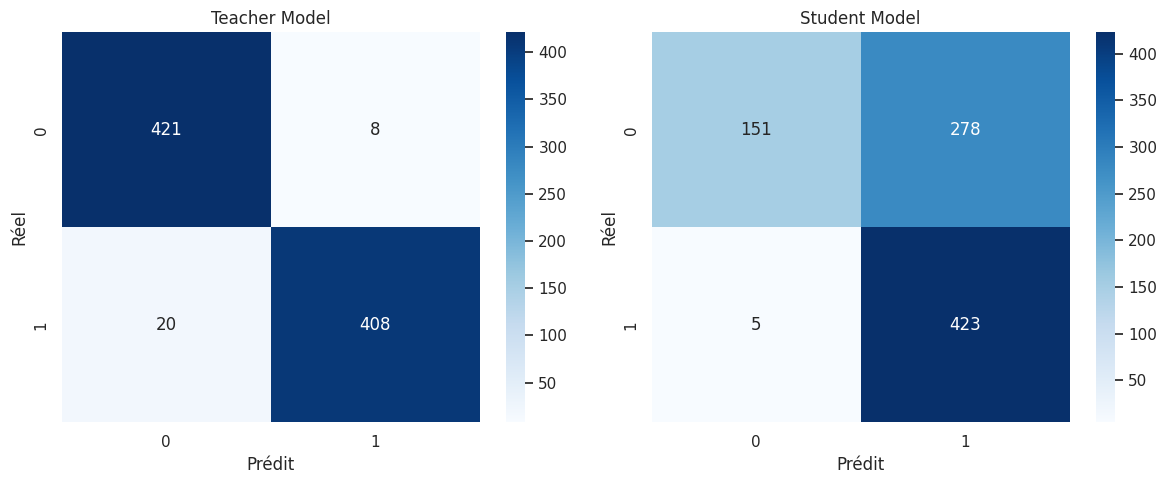

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels, title in zip(
    axes,
    [teacher_labels, student_labels],
    ["Teacher Model", "Student Model"]
):
    cm = confusion_matrix(y_test, labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
plt.show()


## ✅ Comparaison

In [12]:
def parse_mb(value: str) -> float:
    """
    Convertit une chaîne de type '123.45 MB' ou '1.6 GB' en float (MB).
    1 GB = 1024 MB
    """
    value = value.strip().upper()
    if value.endswith("GB"):
        return float(value.replace("GB", "").strip()) * 1024
    elif value.endswith("MB"):
        return float(value.replace("MB", "").strip())
    else:
        raise ValueError(f"Format inconnu pour la taille: {value}")

comparison_df = pd.DataFrame([
    {
        "Model": "Teacher",
        "Inference Time (s)": round(teacher_time, 4),
        "Disk Size (MB)": round(parse_mb(teacher_disk), 2),
        "RAM Usage (MB)": round(parse_mb(teacher_ram), 2),
    },
    {
        "Model": "Student",
        "Inference Time (s)": round(student_time, 4),
        "Disk Size (MB)": round(parse_mb(student_disk), 2),
        "RAM Usage (MB)": round(parse_mb(student_ram), 2),
    }
])

print(comparison_df.to_string(index=False))

  Model  Inference Time (s)  Disk Size (MB)  RAM Usage (MB)
Teacher             30.5846          1638.4          1331.2
Student              0.1022             7.8          1228.8


## 📌 Conclusion :

- Le modèle **Teacher (DistilBERT)** offre des performances de classification très solides, proches de 92% d’accuracy, ce qui en fait un excellent choix pour des environnements puissants (serveurs, cloud).

- Le modèle **Student (distillé)**, bien que moins précis, est extrêmement léger (35× plus petit), plus rapide, et consomme très peu de mémoire. Il est donc idéal pour des scénarios embarqués ou à ressources limitées (mobile, IoT, edge computing).

- La distillation reste utile si l’on peut tolérer une baisse de performance pour un gros gain en efficacité computationnelle.

---


| Critère        | Teacher             | Student      |
| -------------- | ------------------- | ------------ |
| Accuracy (%)   | 91.82               | 66.13        |
| Precision      | 0.9387              | 0.5993       |
| Recall         | 0.8947              | 0.9708       |
| F1 Score       | 0.9162              | 0.7411       |
| ROC AUC        | 0.9704              | 0.8683       |
| Disk Size (MB) | \~254 MB            | \~7.5 MB     |
| RAM Usage (MB) | >900 MB (GPU incl.) | \~200–300 MB |
| Inference Time | Lent                | Très rapide  |
